# K-means Clustering Algorithm

You will implement the K-means unsupervised learning algorithm.

Use the simplified Iris dataset provided to test your code.

Column 1: sepal length.
Column 2: sepal width

50 samples for setosa, 50 samples for versicolor

   


(100, 2)


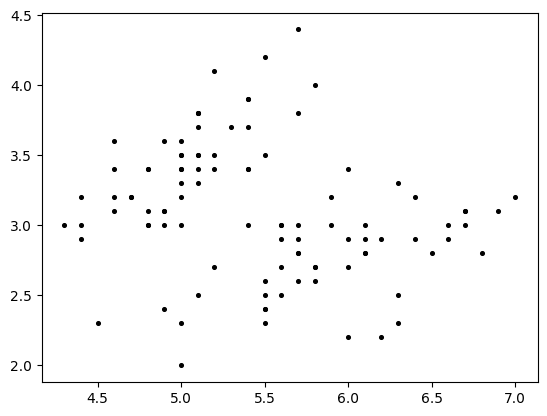

In [18]:
# Load dataset and plot it

%matplotlib inline
import numpy as np
import pandas as pd
from copy import deepcopy
from matplotlib import pyplot as plt

df = pd.read_csv('simple_iris_dataset.csv')

df1 = df['sepal_length'].values
df2 = df['sepal_width'].values
X = np.array(list(zip(df1, df2)))   # 100 x 2
plt.scatter(df1, df2, c='black', s=7)
print(X.shape)

In [19]:
def plot_clusters(X, clusters, centroids):
    """
      X : unlabeled data set, dimension=Nx2.
      clusters: N-dimensional vector indicating the cluster assignment
        of each data point in X.
              [0, 1, 1, ...]
      centroids: 2x2 matrix, the row contains the coordinates of the centroids.
        [[centroid 1 - 1x2 vector]
         [centroid 2 - 1x2 vector]]

    """
    colors = ['r', 'g', 'b', 'y', 'c', 'm']
    k,_ = np.shape(centroids)

    fig, ax = plt.subplots()
    for i in range(k):
        print(colors[i])
        points = np.array([X[j] for j in range(len(X)) if clusters[j] == i])
        plt.scatter(points[:, 0], points[:, 1], s=7, c=colors[i])

    plt.scatter(centroids[:,0], centroids[:,1], marker='*', s=150, c='y')


In [20]:
np.random.seed(0) # for reproducibility
k = 2 # Number of clusters
indices = np.random.choice(len(X), k, replace=False)
centroids = X[indices]
print("Initial Centroids:\n", centroids)

Initial Centroids:
 [[6.1 3. ]
 [6.  2.7]]


In [21]:
max_iterations = 100
iterations = 0
clusters = np.zeros(len(X))

# Loop until convergence or max_iterations
for i in range(max_iterations):
    previous_centroids = deepcopy(centroids)

    # Assign each data point to the closest centroid
    for j, x in enumerate(X):
        distances = [np.linalg.norm(x - c) for c in centroids]
        cluster_assignment = np.argmin(distances)
        clusters[j] = cluster_assignment

    # Recalculate centroids
    new_centroids = deepcopy(centroids)
    for c_id in range(k):
        points_in_cluster = X[clusters == c_id]
        if len(points_in_cluster) > 0:
            new_centroids[c_id] = np.mean(points_in_cluster, axis=0)

    centroids = new_centroids
    iterations += 1

    # Check for convergence
    if np.array_equal(centroids, previous_centroids):
        break

print("Final Centroids:\n", centroids)
print("First 10 cluster assignments:", clusters[:10])
print("Total iterations:", iterations)

Final Centroids:
 [[6.02666667 2.79111111]
 [5.01636364 3.35090909]]
First 10 cluster assignments: [0. 1. 0. 1. 0. 0. 1. 1. 1. 1.]
Total iterations: 10


r
g


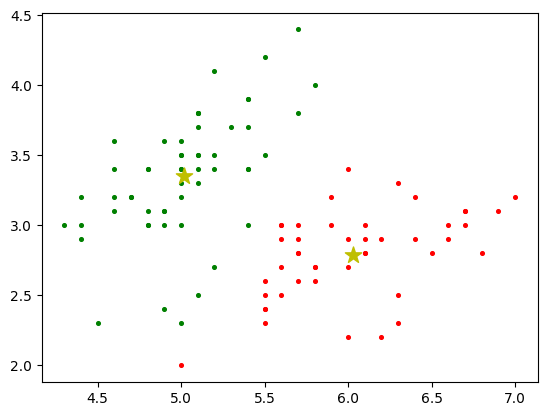

In [22]:
plot_clusters(X, clusters, centroids)